In [1]:
import pandas as pd

In [2]:
import os
os.getcwd()

'/Users/liuyixiao/taobao-user-behavior-analysis/notebooks'

In [4]:
import os
os.listdir("../data")

['.DS_Store', 'processed', 'raw']

In [5]:
os.listdir("../data/raw")

['UserBehavior.csv']

In [6]:
df=pd.read_csv("../data/raw/UserBehavior.csv")

In [7]:
df.head()

,1,2268318,2520377,pv,1511544070
0,1,2333346,2520771,pv,1511561733
1,1,2576651,149192,pv,1511572885
2,1,3830808,4181361,pv,1511593493
3,1,4365585,2520377,pv,1511596146
4,1,4606018,2735466,pv,1511616481


In [8]:
df = pd.read_csv(
    "../data/raw/UserBehavior.csv",
    names=["user_id", "item_id", "category_id", "behavior_type", "timestamp"]
)

In [9]:
df.head()

,user_id,item_id,category_id,behavior_type,timestamp
0,1,2268318,2520377,pv,1511544070
1,1,2333346,2520771,pv,1511561733
2,1,2576651,149192,pv,1511572885
3,1,3830808,4181361,pv,1511593493
4,1,4365585,2520377,pv,1511596146


In [10]:
df.shape

(100150807, 5)

In [12]:
df.info()

print("\n行为类型分布")
print(df["behavior_type"].value_counts())

print("\n核心对象数量：")
print("用户数：", df["user_id"].nunique())
print("商品数：", df["item_id"].nunique())
print("类目数：", df["category_id"].nunique())

print("\n缺失值数量：")
print(df.isnull().sum())

print("\n重复行数量：")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100150807 entries, 0 to 100150806
Data columns (total 5 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   user_id        int64 
 1   item_id        int64 
 2   category_id    int64 
 3   behavior_type  object
 4   timestamp      int64 
dtypes: int64(4), object(1)
memory usage: 3.7+ GB

行为类型分布
behavior_type
pv      89716264
cart     5530446
fav      2888258
buy      2015839
Name: count, dtype: int64

核心对象数量：
用户数： 987994
商品数： 4162024
类目数： 9439

缺失值数量：
user_id          0
item_id          0
category_id      0
behavior_type    0
timestamp        0
dtype: int64

重复行数量：
49


In [13]:
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s")

df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour

df.head()

,user_id,item_id,category_id,behavior_type,timestamp,datetime,date,hour
0,1,2268318,2520377,pv,1511544070,2017-11-24 17:21:10,2017-11-24,17
1,1,2333346,2520771,pv,1511561733,2017-11-24 22:15:33,2017-11-24,22
2,1,2576651,149192,pv,1511572885,2017-11-25 01:21:25,2017-11-25,1
3,1,3830808,4181361,pv,1511593493,2017-11-25 07:04:53,2017-11-25,7
4,1,4365585,2520377,pv,1511596146,2017-11-25 07:49:06,2017-11-25,7


In [14]:
print("最早时间：", df["datetime"].min())
print("最晚时间：", df["datetime"].max())
print("日期范围：")
print(df["date"].value_counts().sort_index())

最早时间： 1902-05-07 22:32:46
最晚时间： 2037-04-09 05:22:35
日期范围：
date
1902-05-07     2
1905-07-13    28
1910-07-22     1
1911-03-24     1
1918-04-15     4
              ..
2033-03-19    12
2036-10-20     3
2036-10-21     1
2036-10-22    25
2037-04-09     1
Name: count, Length: 348, dtype: int64


In [16]:
for col in ["datetime", "date", "hour"]:
    if col in df.columns:
        df = df.drop(columns=[col])

df["datetime"] = (
    pd.to_datetime(df["timestamp"], unit="s", utc=True)
      .dt.tz_convert("Asia/Shanghai")
      .dt.tz_localize(None)
)

start_time = "2017-11-25"
end_time = "2017-12-04"
df_clean = df[
    (df["datetime"] >= start_time) &
    (df["datetime"] < end_time)
].copy()

df_clean["date"] = df_clean["datetime"].dt.date
df_clean["hour"] = df_clean["datetime"].dt.hour

df_clean = df_clean.drop_duplicates()
df_clean["user_id"] = df_clean["user_id"].astype("int32")
df_clean["item_id"] = df_clean["item_id"].astype("int32")
df_clean["category_id"] = df_clean["category_id"].astype("int32")
df_clean["behavior_type"] = df_clean["behavior_type"].astype("category")
df_clean["hour"] = df_clean["hour"].astype("int8")

print("清洗前数据量：", len(df))
print("清洗后数据量：", len(df_clean))
print("删除数据量：", len(df) - len(df_clean))
print("\n清洗后时间范围：")
print(df_clean["datetime"].min())
print(df_clean["datetime"].max())
print("\n清洗后行为分布：")
print(df_clean["behavior_type"].value_counts())
print("\n清洗后内存信息：")

df_clean.info()

清洗前数据量： 100150807
清洗后数据量： 100095182
删除数据量： 55625

清洗后时间范围：
2017-11-25 00:00:00
2017-12-03 23:59:59

清洗后行为分布：
behavior_type
pv      89660671
cart     5530446
fav      2888258
buy      2015807
Name: count, dtype: int64

清洗后内存信息：
<class 'pandas.core.frame.DataFrame'>
Index: 100095182 entries, 0 to 100150806
Data columns (total 8 columns):
 #   Column         Dtype         
---  ------         -----         
 0   user_id        int32         
 1   item_id        int32         
 2   category_id    int32         
 3   behavior_type  category      
 4   timestamp      int64         
 5   datetime       datetime64[ns]
 6   date           object        
 7   hour           int8          
dtypes: category(1), datetime64[ns](1), int32(3), int64(1), int8(1), object(1)
memory usage: 4.3+ GB


In [18]:
total_records=len(df_clean)

total_pv=df_clean[df_clean["behavior_type"]=="pv"].shape[0]
total_uv=df_clean["user_id"].nunique()
total_buy=df_clean[df_clean["behavior_type"] == "buy"].shape[0]
buy_users=df_clean.loc[df_clean["behavior_type"]=="buy", "user_id"].nunique()
total_items=df_clean["item_id"].nunique()
total_categories=df_clean["category_id"].nunique()
pv_to_buy_rate=total_buy/total_pv
user_conversion_rate=buy_users/total_uv

print("总行为记录数：", total_records)
print("总浏览量 PV：", total_pv)
print("独立用户数 UV：", total_uv)
print("商品数：", total_items)
print("类目数：", total_categories)
print("总购买次数：", total_buy)
print("购买用户数：", buy_users)
print("浏览-购买转化率：", round(pv_to_buy_rate * 100, 2), "%")
print("用户购买转化率：", round(user_conversion_rate * 100, 2), "%")


总行为记录数： 100095182
总浏览量 PV： 89660671
独立用户数 UV： 987991
商品数： 4161138
类目数： 9437
总购买次数： 2015807
购买用户数： 672404
浏览-购买转化率： 2.25 %
用户购买转化率： 68.06 %


In [22]:
behavior_counts=df_clean["behavior_type"].value_counts()

funnel=pd.DataFrame({
    "behavior_type":["pv","fav","cart","buy"],
    "behavior_name":["浏览","收藏","加购","购买"],
    "count":[
        behavior_counts.get("pv",0),
        behavior_counts.get("fav",0),
        behavior_counts.get("cart", 0),
        behavior_counts.get("buy", 0)
    ]
})

pv_count = funnel.loc[funnel["behavior_type"] == "pv", "count"].values[0]
funnel["rate_vs_pv"] = funnel["count"] / pv_count
funnel["rate_vs_pv_percent"] = (funnel["rate_vs_pv"] * 100).round(2)

funnel

,behavior_type,behavior_name,count,rate_vs_pv,rate_vs_pv_percent
0,pv,浏览,89660671,1.000000,100.00
1,fav,收藏,2888258,0.032213,3.22
2,cart,加购,5530446,0.061682,6.17
3,buy,购买,2015807,0.022483,2.25


In [24]:
daily_behavior=(
    df_clean
    .groupby(["date","behavior_type"],observed=True)
    .size()
    .reset_index(name="count")
)

daily_behavior_pivot=daily_behavior.pivot(
    index="date",
    columns="behavior_type",
    values="count"
).fillna(0).astype(int)

daily_behavior_pivot

behavior_type,buy,cart,fav,pv
date,,,,
2017-11-25,201144,563376,302071,9353416
2017-11-26,205638,582581,308954,9567422
2017-11-27,226834,541904,291221,9041186
2017-11-28,211997,534157,289100,8842932
2017-11-29,223068,551593,298587,9210820
2017-11-30,221459,565015,302264,9358998
2017-12-01,210010,623346,307115,9718956
2017-12-02,257903,793569,396749,12329641
2017-12-03,257754,774905,392197,12237300


In [25]:
#每日行为趋势显示，2017-12-02 和 2017-12-03 的浏览、加购、收藏、购买行为均明显高于前几日，说明用户活跃度在周末出现显著提升。

In [26]:
hourly_behavior=(
    df_clean
    .groupby(["hour","behavior_type"],observed=True)
    .size()
    .reset_index(name="count")
)

hourly_behavior_pivot=hourly_behavior.pivot(
    index="hour",
    columns="behavior_type",
    values="count"
).fillna(0).astype(int)

hourly_behavior_pivot

behavior_type,buy,cart,fav,pv
hour,,,,
0,57775,181807,105681,3056935
1,23169,85412,51374,1421673
2,12012,46155,27791,769269
3,8025,32552,18384,524992
4,6748,28537,14793,449628
5,8135,37264,18992,581694
6,18014,81305,40524,1226653
7,37679,147046,74666,2228959
8,64916,192036,103721,3042342


In [27]:
#用户浏览和购买高峰集中在晚间 20:00-22:00，说明用户更倾向于在晚间进行商品浏览和购买决策。平台可将优惠券推送、商品推荐、直播活动、限时促销等运营动作重点安排在晚间高活跃时段，以提升转化效率。

In [29]:
for behavior in ["pv","fav","cart","buy"]:
    peak_hour=hourly_behavior_pivot[behavior].idxmax()
    peak_count=hourly_behavior_pivot[behavior].max()
    print(f"{behavior}高峰小时:{peak_hour}点,行为次数{peak_count}")

pv高峰小时:21点,行为次数7538382
fav高峰小时:22点,行为次数232222
cart高峰小时:22点,行为次数486249
buy高峰小时:21点,行为次数145431


In [31]:
#从小时维度看，用户行为高峰主要集中在晚间 21:00-22:00。
#其中，浏览行为和购买行为均在 21 点达到峰值，收藏和加购行为在 22 点达到峰值。
#说明用户更倾向于在晚间进行商品浏览和购买决策，平台可将优惠券推送、商品推荐、直播活动或限时促销安排在 20:00-22:00，以提高营销触达和购买转化效率。

In [34]:
buy_data=df_clean[df_clean["behavior_type"]=="buy"]
user_buy_count=buy_data.groupby("user_id").size()
total_buy_users=user_buy_count.shape[0]
repeat_buy_users=(user_buy_count>=2).sum()
repeat_purchase_rate=repeat_buy_users/total_buy_users

print("购买用户数：", total_buy_users)
print("复购用户数：", repeat_buy_users)
print("复购率：", round(repeat_purchase_rate * 100, 2), "%")

user_buy_count.describe()

购买用户数： 672404
复购用户数： 443858
复购率： 66.01 %


count    672404.00000
mean          2.99791
std           2.89428
min           1.00000
25%           1.00000
50%           2.00000
75%           4.00000
max         262.00000
dtype: float64

In [36]:
user_behavior = (
    df_clean
    .groupby(["user_id", "behavior_type"], observed=True)
    .size()
    .reset_index(name="count")
)
user_behavior_pivot = user_behavior.pivot(
    index="user_id",
    columns="behavior_type",
    values="count"
).fillna(0).astype(int)
user_active_days = (
    df_clean
    .groupby("user_id")["date"]
    .nunique()
)

user_profile=user_behavior_pivot.copy()
user_profile["active_days"]=user_active_days
user_profile["cart_to_buy_rate"] = user_profile["buy"] / user_profile["cart"].replace(0, pd.NA)

user_profile.head()


behavior_type,buy,cart,fav,pv,active_days,cart_to_buy_rate
user_id,,,,,,
1,0,0,0,55,9,<NA>
2,7,3,7,54,8,2.333333
3,0,15,5,33,9,0.0
4,4,13,0,268,7,0.307692
5,0,0,0,64,6,<NA>


In [39]:
buy_q75=user_profile["buy"].quantile(0.75)
pv_q75 = user_profile["pv"].quantile(0.75)
active_q75 = user_profile["active_days"].quantile(0.75)
cart_q75 = user_profile["cart"].quantile(0.75)

def classify_user(row):
    if row["buy"]>=buy_q75 and row["active_days"]>=active_q75:
        return "高价值用户"
    elif row["cart"]>=cart_q75 and row["buy"]== 0:
        return "潜力转化用户"
    elif row["pv"]>=pv_q75 and row["buy"]==0:
        return "高浏览未购买用户"
    elif row["buy"]>0:
        return "普通购买用户"
    else:
        return "低活跃用户"


user_profile["user_segment"]=user_profile.apply(classify_user,axis=1)


segment_summary = (
    user_profile["user_segment"]
    .value_counts()
    .reset_index()
)
segment_summary.columns = ["user_segment", "user_count"]
segment_summary["user_ratio"] = (
    segment_summary["user_count"] / segment_summary["user_count"].sum() * 100
).round(2)

segment_summary

,user_segment,user_count,user_ratio
0,普通购买用户,559914,56.67
1,低活跃用户,229975,23.28
2,高价值用户,112490,11.39
3,潜力转化用户,53132,5.38
4,高浏览未购买用户,32480,3.29


In [40]:
item_behavior = (
    df_clean
    .groupby(["item_id", "behavior_type"], observed=True)
    .size()
    .reset_index(name="count")
)
item_behavior_pivot = item_behavior.pivot(
    index="item_id",
    columns="behavior_type",
    values="count"
).fillna(0).astype(int)

for col in ["pv", "fav", "cart", "buy"]:
    if col not in item_behavior_pivot.columns:
        item_behavior_pivot[col] = 0

item_profile = item_behavior_pivot.copy()
item_profile["buy_conversion_rate"] = item_profile["buy"] / item_profile["pv"].replace(0, pd.NA)
item_profile["cart_rate"] = item_profile["cart"] / item_profile["pv"].replace(0, pd.NA)
item_profile["fav_rate"] = item_profile["fav"] / item_profile["pv"].replace(0, pd.NA)
item_profile.head()

behavior_type,buy,cart,fav,pv,buy_conversion_rate,cart_rate,fav_rate
item_id,,,,,,,
1,0,0,0,2,0.0,0.0,0.0
3,0,0,0,2,0.0,0.0,0.0
4,0,0,0,3,0.0,0.0,0.0
5,0,0,0,2,0.0,0.0,0.0
6,0,0,0,1,0.0,0.0,0.0


In [41]:
item_profile["pv"].describe()

min_pv = 100
item_profile_valid = item_profile[item_profile["pv"] >= min_pv].copy()
print("原始商品数量：", item_profile.shape[0])
print("过滤后商品数量：", item_profile_valid.shape[0])
print("过滤比例：", round(item_profile_valid.shape[0] / item_profile.shape[0] * 100, 2), "%")
item_profile_valid.head()

原始商品数量： 4161138
过滤后商品数量： 164798
过滤比例： 3.96 %


behavior_type,buy,cart,fav,pv,buy_conversion_rate,cart_rate,fav_rate
item_id,,,,,,,
72,3,15,12,289,0.010381,0.051903,0.041522
81,14,45,39,564,0.024823,0.079787,0.069149
116,10,32,2,134,0.074627,0.238806,0.014925
142,8,15,5,242,0.033058,0.061983,0.020661
207,3,18,14,224,0.013393,0.080357,0.0625


In [42]:
pv_q75 = item_profile_valid["pv"].quantile(0.75)
conversion_q25 = item_profile_valid["buy_conversion_rate"].quantile(0.25)

high_exposure_low_conversion = item_profile_valid[
    (item_profile_valid["pv"] >= pv_q75) &
    (item_profile_valid["buy_conversion_rate"] <= conversion_q25)
].sort_values(by="pv", ascending=False)

high_exposure_low_conversion.head(10)

behavior_type,buy,cart,fav,pv,buy_conversion_rate,cart_rate,fav_rate
item_id,,,,,,,
2032668,57,517,517,19141,0.002978,0.02701,0.02701
59883,39,366,273,17404,0.002241,0.02103,0.015686
3371523,7,50,14,17159,0.000408,0.002914,0.000816
2367945,0,2,1,16190,0.0,0.000124,0.000062
1591862,0,4,2,16185,0.0,0.000247,0.000124
1164931,15,505,400,10656,0.001408,0.047391,0.037538
4622270,20,201,250,10414,0.00192,0.019301,0.024006
1699547,25,447,264,9749,0.002564,0.045851,0.02708
2400640,21,94,108,8912,0.002356,0.010548,0.012118


In [46]:
### 高曝光低转化商品分析结论
#通过对商品浏览量和购买转化率进行分位数筛选，筛选出浏览量处于前 25%、但购买转化率处于后 25% 的商品，定义为“高曝光低转化商品”。
#这类商品具备较高曝光，但购买转化表现较弱，说明用户虽然被商品吸引并产生浏览行为，但最终购买意愿不足。可能原因包括商品详情页说服力不足、价格竞争力不强、评价或销量影响购买决策，或者商品主图/标题与实际商品匹配度不高。
#对于这类商品，建议优先进行商品详情页优化、价格策略调整、优惠券测试、评价展示优化，以及主图和标题匹配度检查，以提升从浏览到购买的转化效率。

In [44]:
pv_q50 = item_profile_valid["pv"].quantile(0.50)
conversion_q75 = item_profile_valid["buy_conversion_rate"].quantile(0.75)
low_exposure_high_conversion = item_profile_valid[
    (item_profile_valid["pv"] <= pv_q50) &
    (item_profile_valid["buy_conversion_rate"] >= conversion_q75)
].sort_values(by="buy_conversion_rate", ascending=False)
low_exposure_high_conversion.head(10)

behavior_type,buy,cart,fav,pv,buy_conversion_rate,cart_rate,fav_rate
item_id,,,,,,,
3557522,311,0,7,132,2.356061,0.0,0.05303
1553835,180,0,1,113,1.59292,0.0,0.00885
2162722,184,0,1,172,1.069767,0.0,0.005814
2857971,96,0,0,111,0.864865,0.0,0.0
5118314,134,31,5,160,0.8375,0.19375,0.03125
4889922,101,22,6,131,0.770992,0.167939,0.045802
676683,100,26,10,135,0.740741,0.192593,0.074074
743414,75,31,7,109,0.688073,0.284404,0.06422
5048369,72,0,6,107,0.672897,0.0,0.056075


In [45]:
#潜力商品”，适合增加推荐流量

In [47]:
top_conversion_items = (
    item_profile_valid
    .sort_values(by="buy_conversion_rate", ascending=False)
    .head(10)
)
top_conversion_items

behavior_type,buy,cart,fav,pv,buy_conversion_rate,cart_rate,fav_rate
item_id,,,,,,,
3557522,311,0,7,132,2.356061,0.0,0.05303
1553835,180,0,1,113,1.59292,0.0,0.00885
2162722,184,0,1,172,1.069767,0.0,0.005814
4282175,214,0,1,204,1.04902,0.0,0.004902
555181,292,0,6,309,0.944984,0.0,0.019417
2857971,96,0,0,111,0.864865,0.0,0.0
5118314,134,31,5,160,0.8375,0.19375,0.03125
4865312,244,0,1,301,0.810631,0.0,0.003322
3122135,1408,342,152,1779,0.791456,0.192243,0.085441


In [48]:
user_item_behavior = (
    df_clean
    .groupby(["user_id", "item_id", "behavior_type"], observed=True)
    .size()
    .reset_index(name="count")
)
user_item_path = user_item_behavior.pivot(
    index=["user_id", "item_id"],
    columns="behavior_type",
    values="count"
).fillna(0).astype(int)

for col in ["pv", "fav", "cart", "buy"]:
    if col not in user_item_path.columns:
        user_item_path[col] = 0
        
user_item_path["has_pv"] = user_item_path["pv"] > 0
user_item_path["has_fav"] = user_item_path["fav"] > 0
user_item_path["has_cart"] = user_item_path["cart"] > 0
user_item_path["has_buy"] = user_item_path["buy"] > 0

user_item_path.head()

behavior_type    buy  cart  fav  pv  has_pv  has_fav  has_cart  has_buy
user_id item_id                                                        
1       46259      0     0    0   2    True    False     False    False
        79715      0     0    0   1    True    False     False    False
        230380     0     0    0   1    True    False     False    False
        266784     0     0    0   2    True    False     False    False
        271696     0     0    0   1    True    False     False    False

In [49]:
def get_user_item_path(row):
    if row["has_buy"] and row["has_cart"] and row["has_fav"]:
        return "浏览-收藏-加购-购买"
    elif row["has_buy"] and row["has_cart"]:
        return "浏览-加购-购买"
    elif row["has_buy"] and row["has_fav"]:
        return "浏览-收藏-购买"
    elif row["has_buy"]:
        return "浏览-购买"
    elif row["has_cart"] and row["has_fav"]:
        return "浏览-收藏-加购未购买"
    elif row["has_cart"]:
        return "浏览-加购未购买"
    elif row["has_fav"]:
        return "浏览-收藏未购买"
    else:
        return "仅浏览"

user_item_path["behavior_path"] = user_item_path.apply(get_user_item_path, axis=1)

path_summary = (
    user_item_path["behavior_path"]
    .value_counts()
    .reset_index()
)

path_summary.columns = ["behavior_path", "user_item_count"]
path_summary["ratio"] = (
    path_summary["user_item_count"] / path_summary["user_item_count"].sum() * 100
).round(2)

path_summary

,behavior_path,user_item_count,ratio
0,仅浏览,66327040,87.35
1,浏览-加购未购买,4934810,6.50
2,浏览-收藏未购买,2636128,3.47
3,浏览-购买,1464955,1.93
4,浏览-加购-购买,331818,0.44
5,浏览-收藏-购买,113893,0.15
6,浏览-收藏-加购未购买,104595,0.14
7,浏览-收藏-加购-购买,15361,0.02


In [50]:
## 模块三：用户-商品行为路径分析结论

#本模块为避免用户维度聚合导致的不同行为商品路径混淆问题，以 user_id + item_id 为分析粒度构建用户-商品行为路径表。相比直接在用户维度判断路径，该方法可以保证收藏、加购、购买等行为发生在同一个用户对同一个商品的交互组合中，从而提高路径分析的严谨性。

#路径统计结果显示，在所有用户-商品交互组合中，仅浏览路径占比最高，共 66,327,040 个组合，占比 87.35%。这说明大部分用户与商品的交互停留在浏览阶段，并没有进一步产生收藏、加购或购买行为，用户从浏览到后续强意向行为之间存在明显流失。

#在未购买路径中，浏览-加购未购买路径占比为 6.50%，高于浏览-收藏未购买路径的 3.47%。这说明相比收藏，用户更倾向于通过加入购物车表达购买意向。对于加购但未购买的用户-商品组合，可以通过购物车优惠券、降价提醒、库存提醒等方式促进转化。

#在购买路径中，浏览-购买路径占比为 1.93%，高于浏览-加购-购买路径的 0.44% 和浏览-收藏-购买路径的 0.15%。这说明在当前数据窗口和行为记录口径下，部分购买行为并未伴随收藏或加购行为，用户可能存在较短的购买决策路径。

#完整路径“浏览-收藏-加购-购买”占比仅为 0.02%，说明同时经历收藏、加购和购买的用户-商品组合较少。整体来看，用户行为路径呈现出明显的漏斗特征：大量交互停留在浏览阶段，少部分进入收藏、加购，最终产生购买的比例较低。

#需要说明的是，本模块分析的是用户-商品粒度下的行为组合路径，能够避免不同商品行为被错误合并，但尚未严格判断行为发生的时间顺序。

In [51]:
buy_data = df_clean[df_clean["behavior_type"] == "buy"].copy()

analysis_date = df_clean["datetime"].max() + pd.Timedelta(days=1)

rfm = (
    buy_data
    .groupby("user_id")
    .agg(
        last_buy_time=("datetime", "max"),
        frequency=("behavior_type", "count")
    )
)
rfm["recency"] = (analysis_date - rfm["last_buy_time"]).dt.days

rfm["active_days"] = user_profile["active_days"]
rfm["pv"] = user_profile["pv"]
rfm["cart"] = user_profile["cart"]

rfm.head()

,last_buy_time,frequency,recency,active_days,pv,cart
user_id,,,,,,
2,2017-12-02 19:35:42,7,2,8,54,3
4,2017-11-30 10:23:20,4,4,7,268,13
11,2017-11-25 21:16:32,1,9,8,150,6
16,2017-12-01 23:56:21,2,3,7,72,1
17,2017-12-01 13:28:43,1,3,6,91,3


In [57]:
rfm["R_score"] = pd.qcut(
    rfm["recency"].rank(method="first"),
    q=4,
    labels=[4, 3, 2, 1]
).astype(int)

rfm["F_score"]=pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=4,
    labels=[1,2,3,4]
).astype(int)

rfm["A_score"]=pd.qcut(
    rfm["active_days"].rank(method="first"),
    q=4,
    labels=[1,2,3,4]
).astype(int)

rfm["RFA_score"] = rfm["R_score"] + rfm["F_score"] + rfm["A_score"]

rfm.head()

,last_buy_time,frequency,recency,active_days,pv,cart,R_score,F_score,A_score,RFA_score
user_id,,,,,,,,,,
2,2017-12-02 19:35:42,7,2,8,54,3,3,4,2,9
4,2017-11-30 10:23:20,4,4,7,268,13,2,3,2,7
11,2017-11-25 21:16:32,1,9,8,150,6,1,1,2,4
16,2017-12-01 23:56:21,2,3,7,72,1,3,2,2,7
17,2017-12-01 13:28:43,1,3,6,91,3,3,1,1,5


In [58]:
def classify_rfa_user(row):
    if row["R_score"] >= 3 and row["F_score"] >= 3 and row["A_score"] >= 3:
        return "高价值用户"
    elif row["R_score"] >= 3 and row["F_score"] < 3:
        return "近期购买低频用户"
    elif row["R_score"] < 3 and row["F_score"] >= 3:
        return "高频沉睡用户"
    elif row["RFA_score"] >= 8:
        return "潜力价值用户"
    else:
        return "一般价值用户"

rfm["rfa_segment"] = rfm.apply(classify_rfa_user, axis=1)

rfa_summary = (
    rfm["rfa_segment"]
    .value_counts()
    .reset_index()
)

rfa_summary.columns = ["rfa_segment", "user_count"]

rfa_summary["user_ratio"] = (
    rfa_summary["user_count"] / rfa_summary["user_count"].sum() * 100
).round(2)

rfa_summary

,rfa_segment,user_count,user_ratio
0,一般价值用户,207296,30.83
1,高频沉睡用户,129924,19.32
2,近期购买低频用户,129924,19.32
3,高价值用户,112194,16.69
4,潜力价值用户,93066,13.84


In [59]:
## 模块四：RFM 简化用户价值模型结论

#本模块基于电商用户运营中常用的 RFM 思想，对购买用户进行价值分层。由于当前淘宝用户行为数据中不包含消费金额字段，因此无法构建完整的 RFM 模型。本项目采用简化版本，将 RFM 中的 R 和 F 与用户活跃度结合，构建 RFA 用户价值模型。

#其中，R（Recency）表示用户最近一次购买距离分析基准日的天数，数值越小代表用户最近购买越近；F（Frequency）表示用户在分析周期内的购买次数，数值越高代表购买频率越高；A（Activity）使用用户活跃天数作为补充指标，表示用户在分析周期内的活跃程度。

#在打分方法上，本模块使用分位数分箱方法将 R、F、A 三个指标分别转换为 1 到 4 分。其中，R 指标由于最近购买间隔越小越好，因此采用反向打分；F 和 A 指标数值越大越好，因此采用正向打分。随后将 R_score、F_score 和 A_score 相加得到 RFA_score，并基于 R、F、A 分数规则划分用户价值类型。

#最终用户价值分层结果如下：

#- 一般价值用户：207,296 人，占比 30.83%
#- 高频沉睡用户：129,924 人，占比 19.32%
#- 近期购买低频用户：129,924 人，占比 19.32%
#- 高价值用户：112,194 人，占比 16.69%
#- 潜力价值用户：93,066 人，占比 13.84%

#从结果来看，一般价值用户占比最高，说明仍有较大比例购买用户在最近购买、购买频率和活跃度方面表现一般。高价值用户占比为 16.69%，这部分用户最近购买较近、购买频率较高且活跃天数较多，是平台重点维护的核心用户群体。高频沉睡用户占比为 19.32%，说明部分用户历史购买频率较高，但近期购买不够活跃，存在一定流失风险，适合通过老客召回、专属优惠和个性化推荐进行激活。近期购买低频用户占比为 19.32%，说明部分用户近期有购买行为，但尚未形成稳定复购，适合通过二次购买优惠、关联商品推荐等方式提升复购频率。潜力价值用户占比为 13.84%，说明这部分用户综合表现较好，具备进一步培养价值。

#总体来看，RFA 模型从购买时间、购买频率和用户活跃度三个维度对用户价值进行分层，为高价值用户维护、沉睡用户召回、低频用户复购培养和潜力用户运营提供了数据依据。

In [60]:
import matplotlib.pyplot as plt
import os

plt.rcParams["font.sans-serif"] = ["Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

output_dir = "../outputs"

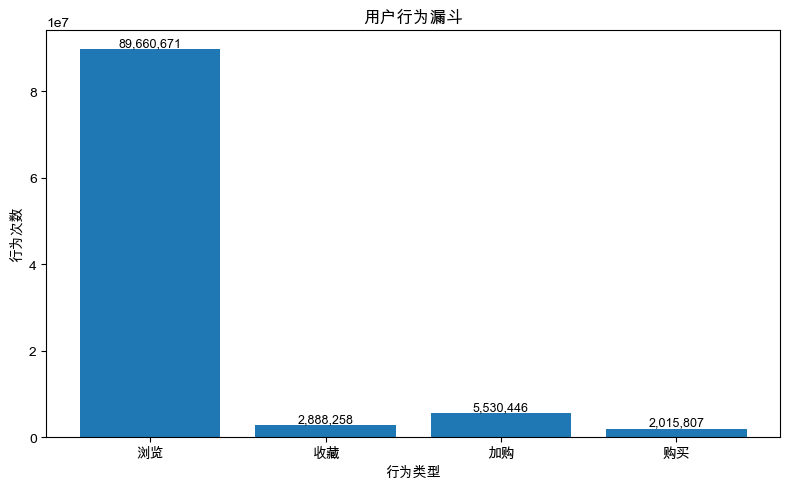

In [61]:
plt.figure(figsize=(8,5))
plt.bar(
    funnel["behavior_name"],
    funnel["count"]
)
plt.title("用户行为漏斗")
plt.xlabel("行为类型")
plt.ylabel("行为次数")

for i ,value in enumerate(funnel["count"]):
    plt.text(
    i,
    value,
    f"{value:,}",
    ha="center",
    va="bottom",
    fontsize=9
)
plt.tight_layout()
plt.savefig(f"{output_dir}/funnel_analysis.png", dpi=300)

plt.show()

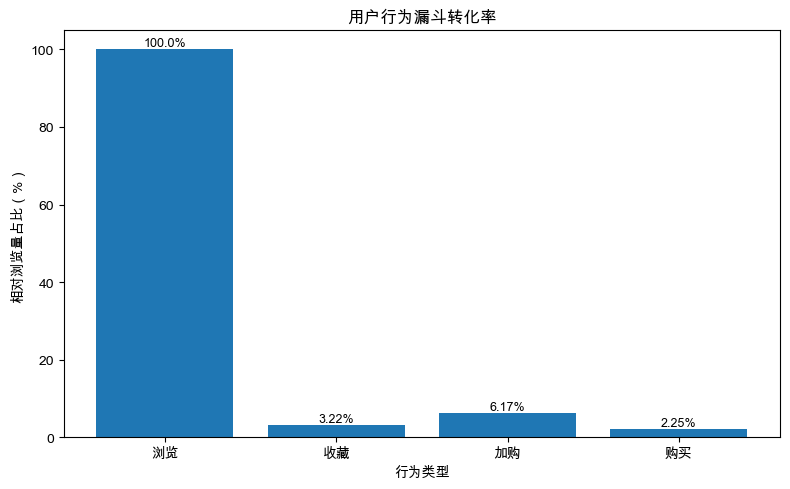

In [62]:
plt.figure(figsize=(8, 5))
plt.bar(
    funnel["behavior_name"],
    funnel["rate_vs_pv_percent"]
)
plt.title("用户行为漏斗转化率")
plt.xlabel("行为类型")
plt.ylabel("相对浏览量占比（%）")
for i, value in enumerate(funnel["rate_vs_pv_percent"]):
    plt.text(
        i,
        value,
        f"{value}%",
        ha="center",
        va="bottom",
        fontsize=9
    )
plt.tight_layout()
plt.savefig(f"{output_dir}/funnel_rate_analysis.png", dpi=300)
plt.show()

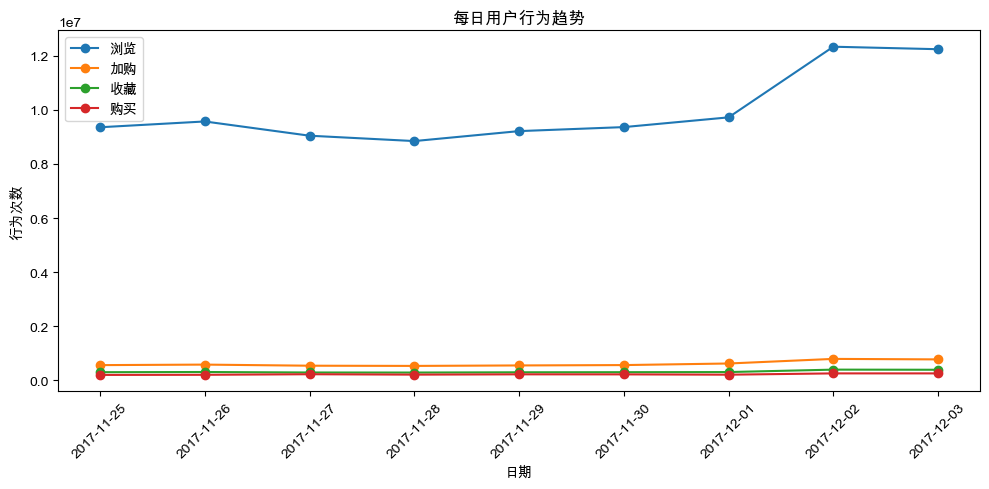

In [63]:
plt.figure(figsize=(10, 5))
plt.plot(
    daily_behavior_pivot.index,
    daily_behavior_pivot["pv"],
    marker="o",
    label="浏览"
)

plt.plot(
    daily_behavior_pivot.index,
    daily_behavior_pivot["cart"],
    marker="o",
    label="加购"
)

plt.plot(
    daily_behavior_pivot.index,
    daily_behavior_pivot["fav"],
    marker="o",
    label="收藏"
)

plt.plot(
    daily_behavior_pivot.index,
    daily_behavior_pivot["buy"],
    marker="o",
    label="购买"
)

plt.title("每日用户行为趋势")
plt.xlabel("日期")
plt.ylabel("行为次数")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/daily_behavior_trend.png", dpi=300)

plt.show()

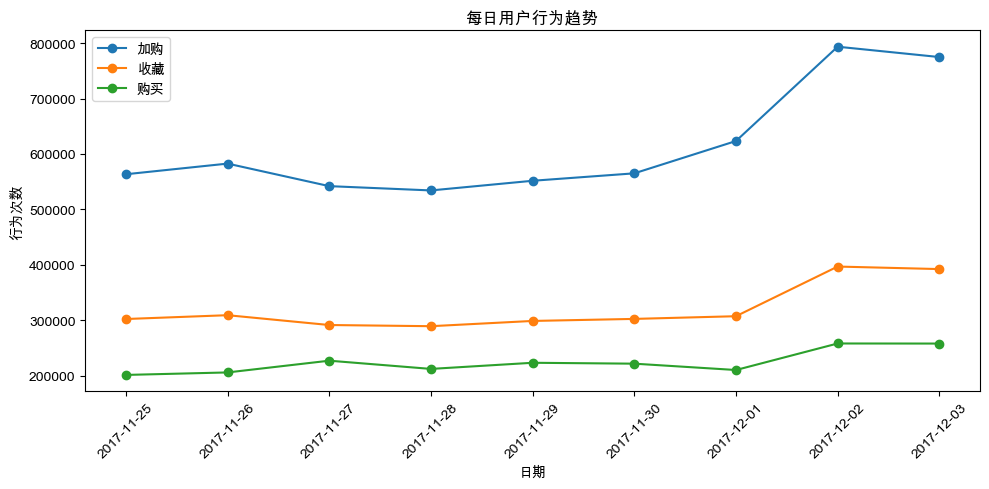

In [64]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_behavior_pivot.index,
    daily_behavior_pivot["cart"],
    marker="o",
    label="加购"
)

plt.plot(
    daily_behavior_pivot.index,
    daily_behavior_pivot["fav"],
    marker="o",
    label="收藏"
)

plt.plot(
    daily_behavior_pivot.index,
    daily_behavior_pivot["buy"],
    marker="o",
    label="购买"
)

plt.title("每日用户行为趋势")
plt.xlabel("日期")
plt.ylabel("行为次数")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/daily_behavior_trend.png", dpi=300)

plt.show()

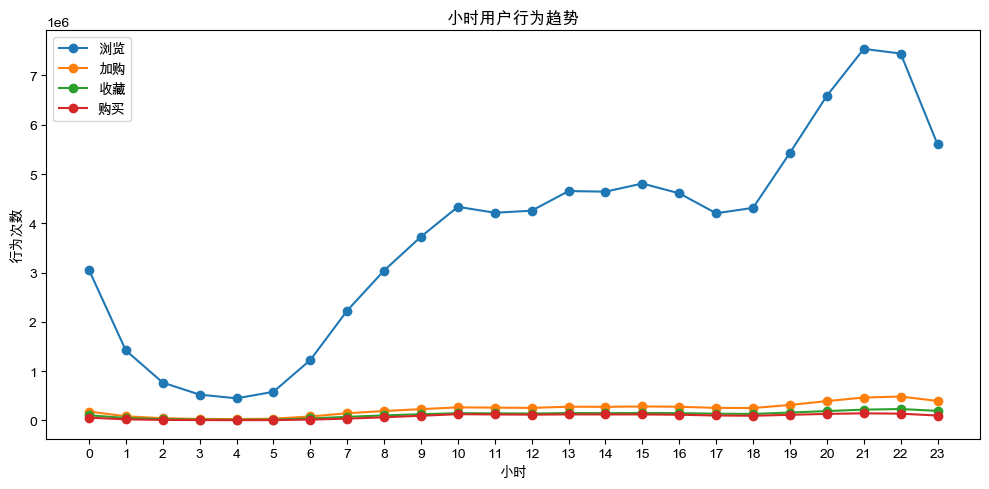

In [65]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_behavior_pivot.index,
    hourly_behavior_pivot["pv"],
    marker="o",
    label="浏览"
)

plt.plot(
    hourly_behavior_pivot.index,
    hourly_behavior_pivot["cart"],
    marker="o",
    label="加购"
)

plt.plot(
    hourly_behavior_pivot.index,
    hourly_behavior_pivot["fav"],
    marker="o",
    label="收藏"

)

plt.plot(
    hourly_behavior_pivot.index,
    hourly_behavior_pivot["buy"],
    marker="o",
    label="购买"
)

plt.title("小时用户行为趋势")
plt.xlabel("小时")
plt.ylabel("行为次数")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/hourly_behavior_trend.png", dpi=300)

plt.show()

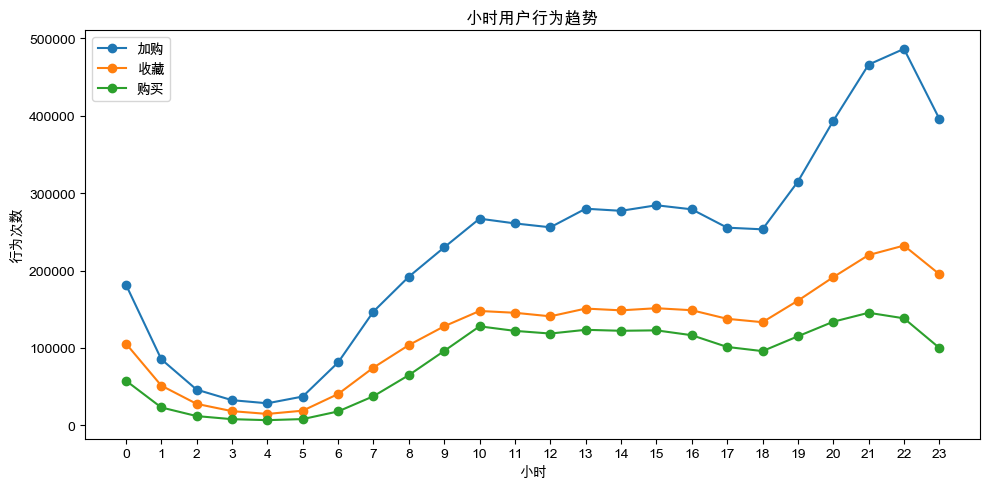

In [66]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_behavior_pivot.index,
    hourly_behavior_pivot["cart"],
    marker="o",
    label="加购"
)

plt.plot(
    hourly_behavior_pivot.index,
    hourly_behavior_pivot["fav"],
    marker="o",
    label="收藏"

)

plt.plot(
    hourly_behavior_pivot.index,
    hourly_behavior_pivot["buy"],
    marker="o",
    label="购买"
)

plt.title("小时用户行为趋势")
plt.xlabel("小时")
plt.ylabel("行为次数")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/hourly_behavior_trend.png", dpi=300)

plt.show()

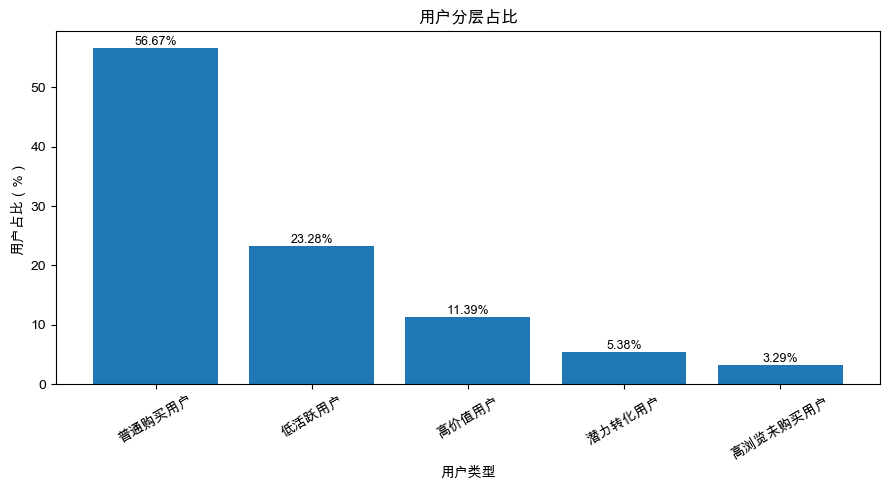

In [68]:
plt.figure(figsize=(9, 5))

plt.bar(
    segment_summary["user_segment"],
    segment_summary["user_ratio"]
)

plt.title("用户分层占比")
plt.xlabel("用户类型")
plt.ylabel("用户占比（%）")
plt.xticks(rotation=30)

for i, value in enumerate(segment_summary["user_ratio"]):
    plt.text(
        i,
        value,
        f"{value}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(f"{output_dir}/user_segment_ratio.png", dpi=300)
plt.show()

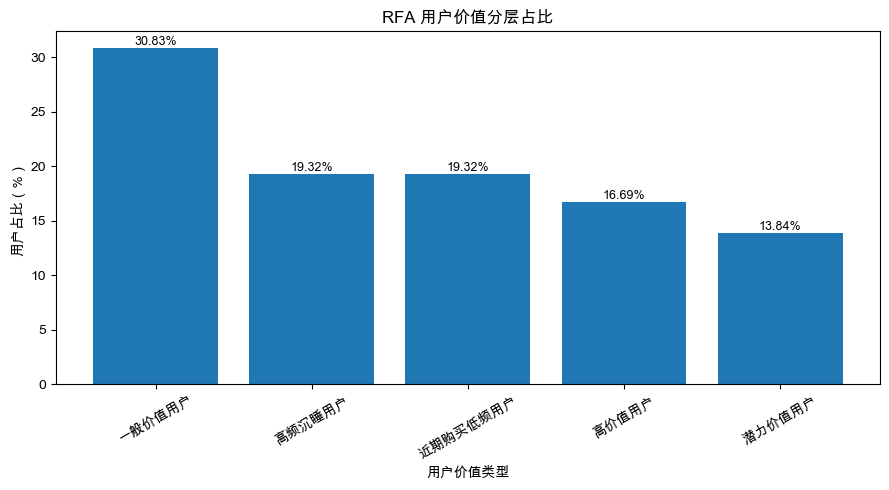

In [69]:
plt.figure(figsize=(9, 5))
plt.bar(
    rfa_summary["rfa_segment"],
    rfa_summary["user_ratio"]
)

plt.title("RFA 用户价值分层占比")
plt.xlabel("用户价值类型")
plt.ylabel("用户占比（%）")
plt.xticks(rotation=30)

for i, value in enumerate(rfa_summary["user_ratio"]):
    plt.text(
        i,
        value,
        f"{value}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(f"{output_dir}/rfa_user_value_segment.png", dpi=300)
plt.show()

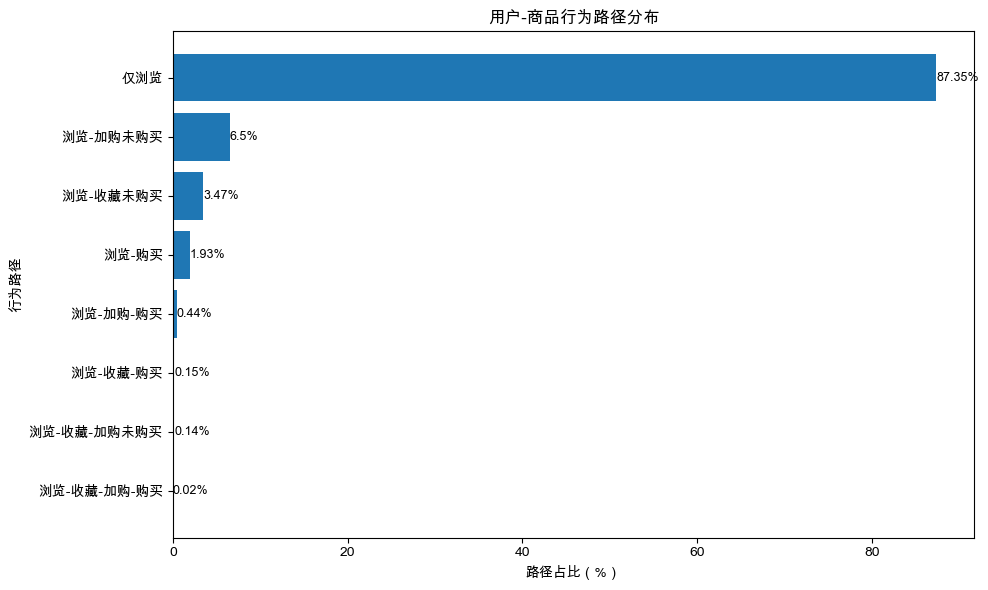

In [70]:
path_plot = path_summary.sort_values("ratio", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    path_plot["behavior_path"],
    path_plot["ratio"]
)

plt.title("用户-商品行为路径分布")
plt.xlabel("路径占比（%）")
plt.ylabel("行为路径")

for i, value in enumerate(path_plot["ratio"]):
    plt.text(
        value,
        i,
        f"{value}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(f"{output_dir}/user_item_behavior_path.png", dpi=300)
plt.show()